In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [30]:
df = pd.read_csv(r'E:\flite\Clean_Dataset.csv')

In [31]:
df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [32]:
df.airline.value_counts()

airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64

In [33]:
df.source_city.value_counts()

source_city
Delhi        61343
Mumbai       60896
Bangalore    52061
Kolkata      46347
Hyderabad    40806
Chennai      38700
Name: count, dtype: int64

In [34]:
df.destination_city.value_counts()

destination_city
Mumbai       59097
Delhi        57360
Bangalore    51068
Kolkata      49534
Hyderabad    42726
Chennai      40368
Name: count, dtype: int64

In [35]:
df.departure_time.value_counts()

departure_time
Morning          71146
Early_Morning    66790
Evening          65102
Night            48015
Afternoon        47794
Late_Night        1306
Name: count, dtype: int64

In [36]:
df.arrival_time.value_counts()

arrival_time
Night            91538
Evening          78323
Morning          62735
Afternoon        38139
Early_Morning    15417
Late_Night       14001
Name: count, dtype: int64

In [37]:
df.stops.value_counts()

stops
one            250863
zero            36004
two_or_more     13286
Name: count, dtype: int64

In [38]:
df['class'].value_counts()

class
Economy     206666
Business     93487
Name: count, dtype: int64

In [39]:
df['duration'].describe()

count    300153.000000
mean         12.221021
std           7.191997
min           0.830000
25%           6.830000
50%          11.250000
75%          16.170000
max          49.830000
Name: duration, dtype: float64

In [41]:
df['duration'].median()

11.25

# Preprocessing 

In [42]:
df = df.drop('Unnamed: 0', axis=1)
df = df.drop('flight', axis=1)

df['class'] = df['class'].apply(lambda x: 1 if x == 'Business' else 0)

In [43]:
df.stops = pd.factorize(df.stops)[0]

In [44]:
df = df.join(pd.get_dummies(df.airline, prefix='airline',dtype=int)).drop('airline',axis=1)
df = df.join(pd.get_dummies(df.source_city, prefix='source',dtype=int)).drop('source_city',axis=1)
df = df.join(pd.get_dummies(df.destination_city, prefix='dest',dtype=int)).drop('destination_city',axis=1)
df = df.join(pd.get_dummies(df.arrival_time, prefix='arrival',dtype=int)).drop('arrival_time',axis=1)
df = df.join(pd.get_dummies(df.departure_time, prefix='departure',dtype=int)).drop('departure_time',axis=1)

In [45]:
df

,stops,class,duration,days_left,price,airline_AirAsia,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,...,arrival_Evening,arrival_Late_Night,arrival_Morning,arrival_Night,departure_Afternoon,departure_Early_Morning,departure_Evening,departure_Late_Night,departure_Morning,departure_Night
0,0,0,2.17,1,5953,0,0,0,0,1,...,0,0,0,1,0,0,1,0,0,0
1,0,0,2.33,1,5953,0,0,0,0,1,...,0,0,1,0,0,1,0,0,0,0
2,0,0,2.17,1,5956,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,0,0,2.25,1,5955,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,0,0,2.33,1,5955,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300148,1,1,10.08,49,69265,0,0,0,0,0,...,1,0,0,0,0,0,0,0,1,0
300149,1,1,10.42,49,77105,0,0,0,0,0,...,0,0,0,1,1,0,0,0,0,0
300150,1,1,13.83,49,79099,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0
300151,1,1,10.00,49,81585,0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,0


## Training Regression Model

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X, y = df.drop('price', axis=1), df['price']

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

In [50]:
reg = RandomForestRegressor(n_jobs=-1)

reg.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1)

In [51]:
reg.score(X_test,y_test)

0.9857183059182004

In [54]:
import math
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = reg.predict(X_test)

print('R2: ',r2_score(y_test, y_pred))
print('MAE: ',mean_absolute_error(y_test, y_pred))
print('MSE: ',mean_squared_error(y_test, y_pred))
print('RMSE: ',math.sqrt(mean_squared_error(y_test, y_pred)))

R2:  0.9857183059182004
MAE:  1067.7758763533686
MSE:  7352210.197514146
RMSE:  2711.495933523439


Text(0.5, 1.0, 'Prediction vs Actual')

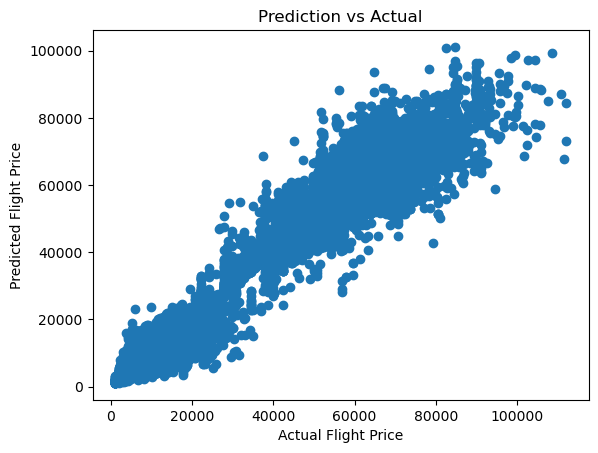

In [55]:
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Flight Price')
plt.ylabel('Predicted Flight Price')
plt.title('Prediction vs Actual')

In [ ]:
# important_features_dict = {}
# for idx, val in enumerate(reg.feature_importances_):
#     important_features_dict[idx] = val

# important_features_list = sorted(important_features_dict,
#                                  key=important_features_dict.get,
#                                  reverse=True)

# print(f'5 most important features: {important_features_list[:5]}')

In [58]:
importances = dict(zip(reg.feature_names_in_, reg.feature_importances_))
sorted_importances = sorted(importances.items(), key=lambda x:x[1], reverse=True)

sorted_importances

[('class', np.float64(0.8799122300203773)),
 ('duration', np.float64(0.057577078720418964)),
 ('days_left', np.float64(0.01868454759586673)),
 ('airline_Vistara', np.float64(0.005289843591713655)),
 ('airline_Air_India', np.float64(0.004720133605485823)),
 ('source_Delhi', np.float64(0.0038467522324786723)),
 ('dest_Delhi', np.float64(0.0034979945978797495)),
 ('source_Mumbai', np.float64(0.0022848021247355798)),
 ('dest_Mumbai', np.float64(0.00198657541880933)),
 ('stops', np.float64(0.0017647863290804863)),
 ('dest_Kolkata', np.float64(0.001738838008542644)),
 ('source_Kolkata', np.float64(0.0017158830728481018)),
 ('dest_Hyderabad', np.float64(0.0017027376403577555)),
 ('arrival_Evening', np.float64(0.0014262821443324367)),
 ('source_Hyderabad', np.float64(0.0012631441846437236)),
 ('arrival_Night', np.float64(0.0011410860560403652)),
 ('departure_Evening', np.float64(0.001104344362623365)),
 ('dest_Bangalore', np.float64(0.0010686721387948561)),
 ('arrival_Afternoon', np.float64(0.

<BarContainer object of 5 artists>

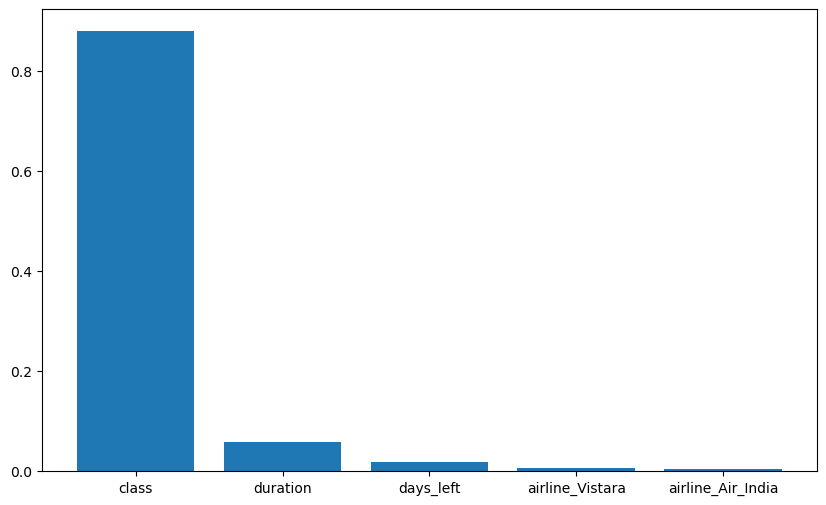

In [59]:
plt.figure(figsize=(10,6))
plt.bar([x[0] for x in sorted_importances[:5]], [x[1] for x in sorted_importances[:5]])

In [60]:
from sklearn.model_selection import GridSearchCV
reg = RandomForestRegressor(n_jobs=-1)

param_grid = {
    'n_estimators' : [100, 200, 300],
    'max_depth' : [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_sample_leaf' : [1, 2, 4],
    'max_features' : ['auto', 'sqrt']
}

grid_search = GridSearchCV(estimator, param_grid, cv=5)
grid_search.fit(X_train, y_train)

best_param = grid_search.best_params_

In [64]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'n_estimators' : randint(100,300),
    'max_depth' : [None, 10, 20, 30, 40, 50],
    'min_samples_split': randint(2,11),
    'min_samples_leaf' : randint(1,5),
    'max_features' : [1.0, 'auto', 'sqrt']
}

reg = RandomForestRegressor(n_jobs=-1)
random_search = RandomizedSearchCV(estimator=reg, param_distributions=param_dist, n_iter=2, cv=3, 
                                   scoring='neg_mean_squared_error', verbose=2, random_state=10, n_jobs=-1)
random_search.fit(X_train,y_train)
best_regressor = random_search.best_estimator_

Fitting 3 folds for each of 2 candidates, totalling 6 fits


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
3 fits failed out of a total of 6.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\USER\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\USER\anaconda3\Lib\site-packages\sklearn\base.py", line 1466, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\Users\USER\anaconda3\Lib\site-packages\sklearn\base.py", line 666, in _validate_params
    validat

In [ ]:
best_regressor.score(X_test, y_test)